In [5]:
import sys
import os
import pandas as pd

# Get the absolute path of the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [6]:
import pickle
import os

# Define the directory and file path
save_dir = "../data/parsed/"
load_path = os.path.join(save_dir, "builder.pkl")

# Load the builder object
with open(load_path, "rb") as f:
    builder = pickle.load(f)

In [7]:
sample = builder.run(builder.timestamps[0])

In [12]:
sample

This pandapower network includes the following parameter tables:
   - bus (118 elements)
   - load (91 elements)
   - gen (321 elements)
   - ext_grid (1 element)
   - line (177 elements)
   - trafo (9 elements)
   - bus_geodata (118 elements)
 and the following results tables:
   - res_bus (118 elements)
   - res_line (177 elements)
   - res_trafo (9 elements)
   - res_ext_grid (1 element)
   - res_load (91 elements)
   - res_gen (321 elements)

In [10]:
def create_generator_output_matrix(builder, num_timestamps=24):  # Default to first 24 hours
    """
    Creates a DataFrame of generator outputs across specified timesteps.
    
    Args:
        builder: PandaPowerFlowBuilder instance
        num_timestamps: Number of timestamps to process
        
    Returns:
        DataFrame where:
        - Index is MultiIndex (generator_name, bus_number, type)
        - Columns are timestamps
        - Values are generator outputs (p_mw)
    """
    # Get first sample to identify all generators
    sample = builder.run(builder.timestamps[0])
    
    # Create generator info with type extracted from name
    generator_info = sample.gen[['name', 'bus']].copy()
    generator_info['type'] = generator_info['name'].apply(lambda x: x.split('_')[0])
    
    multi_index = pd.MultiIndex.from_frame(
        generator_info, 
        names=['generator', 'bus', 'type']
    )
    
    # Use limited number of timestamps
    timestamps = builder.timestamps[:num_timestamps]
    
    # Initialize DataFrame with zeros
    output_matrix = pd.DataFrame(
        index=multi_index,
        columns=timestamps,
        dtype=float
    )
    
    # Fill the matrix with generator outputs for each timestamp
    for timestamp in timestamps:
        sample = builder.run(timestamp)
        output_matrix[timestamp] = sample.res_gen['p_mw'].values
    
    return output_matrix

def plot_generation_by_type(output_matrix):
    """
    Creates plots showing generation by type over time.
    """
    import matplotlib.pyplot as plt
    
    # Aggregate by type
    type_totals = output_matrix.groupby(level='type').sum()
    
    # Create figure
    plt.figure(figsize=(15, 10))
    
    # Plot each type
    for gen_type in type_totals.index:
        plt.plot(type_totals.loc[gen_type], label=gen_type, linewidth=2)
    
    plt.title('Generation by Type Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Power Output (MW)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by Generator Type:")
    print(type_totals.describe())
    
    return type_totals

# Create the matrix for first 24 hours
generator_output_matrix = create_generator_output_matrix(builder, num_timestamps=720)


Summary Statistics by Generator Type:
            Avg (MW)  Max (MW)  Min (MW)  Std Dev  Capacity Factor (%)  \
type                                                                     
combined     3854.82   5832.81   2505.87   746.47                66.09   
combustion   1873.04   2650.41   1069.79   344.52                70.67   
hydro        1492.45   2258.88    998.49   248.62                66.07   
steam         984.23   1479.27    477.50   210.77                66.53   
solar         591.60   2687.78     -0.00   846.40                22.01   
wind          142.60    621.74      0.46   140.50                22.94   
biomass        48.77     71.46     26.95     8.32                68.24   
internal       33.19     43.51     25.05     3.61                76.29   
geothermal      8.14     16.00      0.00     2.96                50.88   

            Generation Mix (%)  
type                            
combined                 42.69  
combustion               20.75  
hydro         

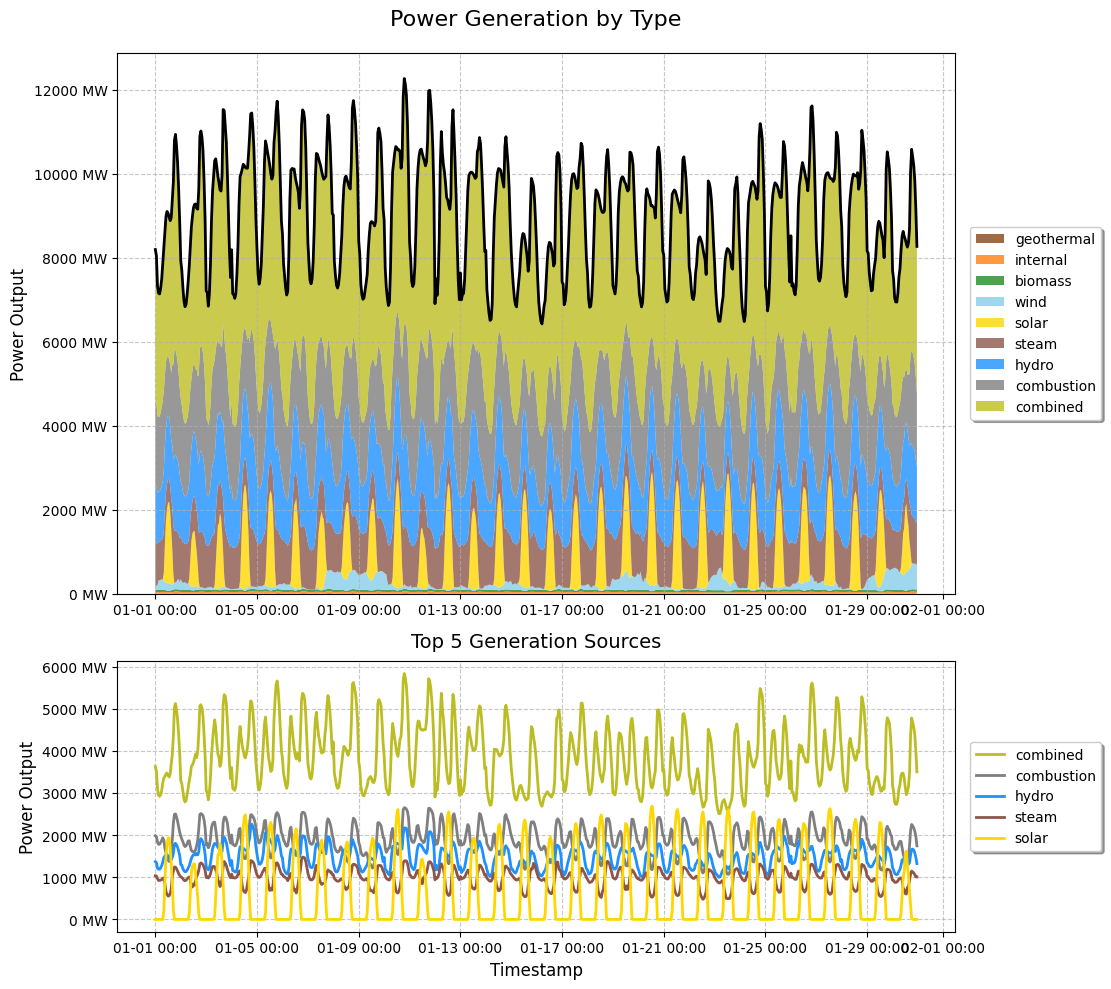

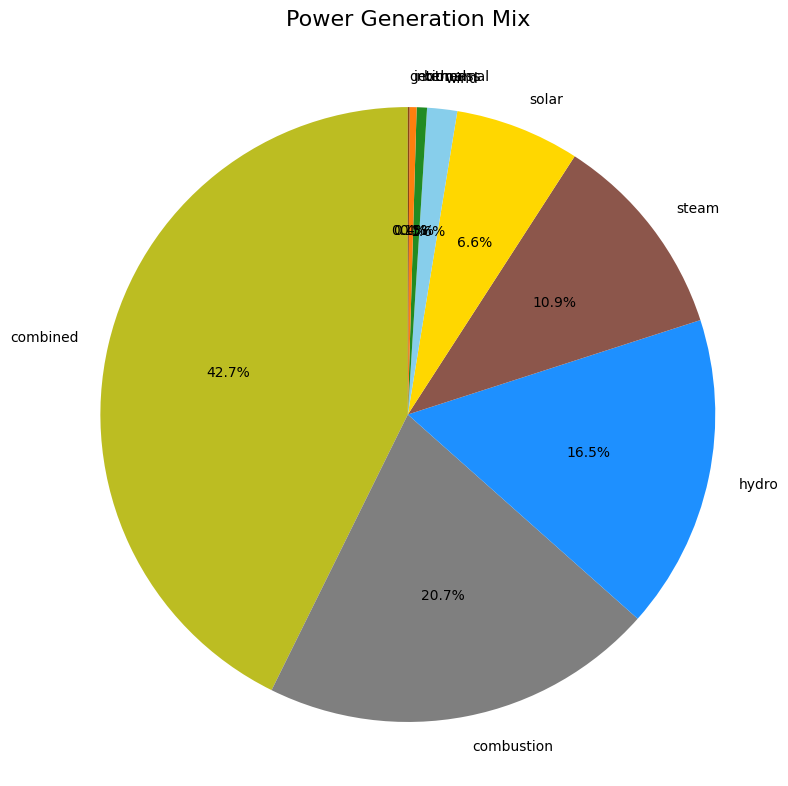

In [11]:
def plot_generation_by_type(output_matrix):
    """
    Creates enhanced visualizations showing generation by type over time.
    """
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import numpy as np
    import pandas as pd
    from matplotlib.ticker import FuncFormatter
    
    # Aggregate by type
    type_totals = output_matrix.groupby(level='type').sum()
    
    # Convert timestamp columns to datetime if they aren't already
    if not isinstance(type_totals.columns[0], pd.Timestamp):
        type_totals.columns = pd.to_datetime(type_totals.columns)
    
    # Set a more appealing color palette
    colors = {
        'solar': '#FFD700',    # Gold
        'wind': '#87CEEB',     # Sky Blue
        'hydro': '#1E90FF',    # Dodger Blue
        'nuclear': '#800080',  # Purple
        'gas': '#FF6347',      # Tomato
        'coal': '#696969',     # Dim Gray
        'biomass': '#228B22',  # Forest Green
        'geothermal': '#8B4513', # Saddle Brown
        'oil': '#A52A2A',      # Brown
        'battery': '#32CD32',  # Lime Green
    }
    
    # Default colors for any types not in our predefined palette
    import matplotlib.cm as cm
    default_colors = cm.tab10.colors
    
    # Create figure with two subplots - stacked area and line
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # 1. STACKED AREA PLOT
    # Sort by average output (larger generators at bottom)
    sorted_types = type_totals.mean(axis=1).sort_values().index
    
    # Get colors for each generator type
    plot_colors = [colors.get(t, default_colors[i % len(default_colors)]) for i, t in enumerate(sorted_types)]
    
    # Create stacked area plot
    ax1.stackplot(type_totals.columns, 
                 [type_totals.loc[t] for t in sorted_types],
                 labels=sorted_types,
                 colors=plot_colors,
                 alpha=0.8)
    
    # Format x-axis for dates
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    
    # Format y-axis with MW
    def megawatt_formatter(x, pos):
        return f'{x:.0f} MW'
    
    ax1.yaxis.set_major_formatter(FuncFormatter(megawatt_formatter))
    
    # Improve the plot appearance
    ax1.set_title('Power Generation by Type', fontsize=16, pad=20)
    ax1.set_ylabel('Power Output', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend outside the plot
    leg1 = ax1.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), 
                     frameon=True, fancybox=True, shadow=True)
    
    # Calculate and show total generation
    total_generation = type_totals.sum()
    ax1.plot(type_totals.columns, total_generation, 
             color='black', linewidth=2, linestyle='-', 
             label='Total')
    
    # 2. LINE PLOT FOR INDIVIDUAL CONTRIBUTIONS
    # Get top 5 contributors by average output
    top_generators = type_totals.mean(axis=1).nlargest(5).index
    
    for gen_type in top_generators:
        ax2.plot(type_totals.columns, type_totals.loc[gen_type], 
                 label=gen_type, 
                 color=colors.get(gen_type, default_colors[list(sorted_types).index(gen_type) % len(default_colors)]),
                 linewidth=2)
    
    # Format the second axis
    ax2.set_title('Top 5 Generation Sources', fontsize=14, pad=10)
    ax2.set_xlabel('Timestamp', fontsize=12)
    ax2.set_ylabel('Power Output', fontsize=12)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.yaxis.set_major_formatter(FuncFormatter(megawatt_formatter))
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add a legend
    leg2 = ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), 
                     frameon=True, fancybox=True, shadow=True)
    
    # Peak annotation removed as requested
    
    # Tight layout with space for the legend
    plt.tight_layout()
    fig.subplots_adjust(right=0.8)
    
    # Print summary statistics
    print("\nSummary Statistics by Generator Type:")
    stats_df = type_totals.T.describe().T
    # Add additional metrics
    stats_df['capacity_factor'] = stats_df['mean'] / stats_df['max'] * 100
    stats_df['contribution_pct'] = stats_df['mean'] / stats_df['mean'].sum() * 100
    stats_df = stats_df.sort_values('contribution_pct', ascending=False)
    
    # Format the output table
    formatted_stats = stats_df[['mean', 'max', 'min', 'std', 'capacity_factor', 'contribution_pct']]
    formatted_stats.columns = ['Avg (MW)', 'Max (MW)', 'Min (MW)', 'Std Dev', 'Capacity Factor (%)', 'Generation Mix (%)']
    
    print(formatted_stats.round(2))
    
    # Generate a pie chart for generation mix
    plt.figure(figsize=(8, 8))
    plt.pie(stats_df['contribution_pct'], 
            labels=stats_df.index, 
            autopct='%1.1f%%', 
            colors=[colors.get(t, default_colors[list(sorted_types).index(t) % len(default_colors)]) for t in stats_df.index],
            startangle=90,
            shadow=False)
    plt.axis('equal')
    plt.title('Power Generation Mix', fontsize=16, pad=20)
    plt.tight_layout()
    
    plt.show()
    
    return type_totals

# Use the improved visualization
type_totals = plot_generation_by_type(generator_output_matrix)